In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import parameters
import plotting_functions as pf
import data_utils as du
import model_utils as mu
import behaviour_analyses as ba
import itertools
import seaborn as sns
from scipy.spatial.distance import cdist

# ADD YOUR DIRECTORIES HERE

path = '/Backup1/LYR/paper/TEM/Summaries/'
save_dirs = [path]

# Choose which training run data to load
date = '2025-12-17'
run = '0'
index_load = None

# Try to find the most recent trained model data to run a forward pass
recent = -1
time_series_smoothing = 0
try:
    # Find model path and iteration index
    save_dir, index = pf.get_model_path(run, date, save_dirs, recent)
    # Run forward path for retrieved model, if folder doesn't exist yet
    model = ba.save_trained_outputs(date, run, int(index), base_path=save_dir, force_overwrite=False, n_envs_save=16, use_old_scripts=True)
except FileNotFoundError:
    print('No trained model weights found for ' + date + ', run ' + run + '.')
    
# Load data, generated either during training or in a forward pass through a trained model
data, para, list_of_files, save_path, env_dict = pf.get_data(save_dirs, run, date, recent, index=index, smoothing=time_series_smoothing, n_envs_save=16)

# Unpack data
x_all = data.x
g_all = data.g
p_all = data.p
acc_s_t_to = data.acc_to
acc_s_t_from = data.acc_from
positions = data.positions
adj = data.adj
x_timeseries = data.x_timeseries
x_gt_timeseries = data.x_gt_timeseries
p_timeseries = data.p_timeseries
p_x_timeseries = data.p_x_timeseries
p_gen_timeseries = data.p_gen_timeseries
g_gen_timeseries = data.g_gen_timeseries
g_timeseries = data.g_timeseries
pos_timeseries = data.pos_timeseries
final_variables = data.final_variables
# Group timeseries together for backward compatibility
timeseries = (g_timeseries, p_timeseries, pos_timeseries)
# Assign parameters
params, widths, n_states = para

# Specify plotting parameters. Some fields will be added after loading data & parameters
plot_specs = mu.DotDict({'smoothing': 0, # spatial ratemap smoothing. Needs to be odd, or 0 for no smoothing
                    'maxmin': True,
                    'cmap': 'jet',
                    'show': True,
                    'circle': True,
                    'g_max_0': False,
                    'p_max_0': True,
                    'save': False,
                    'split_freqs': True,
                    'mult': 4,
                    'cell_num': True,
                    'rectangle': {'marker_size': 20,
                                'marker_shape': 's'},
                    'hexagonal': {'marker_size': 150,
                                'marker_shape': 'H'},
                    'family_tree': {'marker_size': 20,
                                'marker_shape': 'h'},
                    'line_ti': {'marker_size': 20,
                                'marker_shape': 's'},
                    'wood2000': {'marker_size': 150,
                                'marker_shape': 's',
                                'plot_all': False,},
                    'frank2000': {'marker_size': 150,
                                'marker_shape': 's',
                                'plot_all': False,},
                    'grieves2016': {'marker_size': 50,
                                'marker_shape': 'H',
                                'plot_all': False,},
                    'sun2020': {'marker_size': 50,
                                'marker_shape': 's'},
                    'nieh2021': {'marker_size': 50,
                                'marker_shape': 's',
                                'plot_all': False,
                                'smooth': True,
                                'surface': True,},
                    'zhao2025': {'marker_size': 50,
                                'marker_shape': 's'},
                    })

seaborn.set_style(style='white')
seaborn.set_style({'axes.spines.bottom': False,'axes.spines.left': False,'axes.spines.right': \
                False,'axes.spines.top': False})

masks, g_lim, p_lim = pf.sort_data(g_all, p_all, widths, plot_specs)


Not running forward pass: /Backup1/LYR/paper/TEM/Summaries/2026-05-28/run11/save/iter_95000 already exists
yes /Backup1/LYR/paper/TEM/Summaries/2026-05-28/run11/save
Loading model time point 95000
Successfully reconstructed run setup data from test_dict
Successfully loaded timeseries
Successfully reconstructed rate maps from timeseries


In [227]:
masks = [(np.sum(g,1) + np.sum(p,1) != 0).tolist() for g,p in zip(g_all, p_all)]
trainalbe_variables = model.trainable_weights

In [228]:
# np.save('../../plot/data/no_reg_tem_states_cosine_all.npy', np.array(tem_statistic))

In [229]:
for env in range(params.n_envs_save):
    num_correct = np.sum(acc_s_t_to[env] * positions[env])
    proportion = num_correct / sum(positions[env])
    approx_num = proportion * n_states[env]
    print(env, '  Num_states : ', n_states[env], '   Approx proportion : ', np.round(proportion, decimals=3), 
          '   Approx num : ', np.round(approx_num, decimals=0))

0   Num_states :  30    Approx proportion :  [0.771]    Approx num :  [23.]
1   Num_states :  30    Approx proportion :  [0.867]    Approx num :  [26.]
2   Num_states :  30    Approx proportion :  [0.854]    Approx num :  [26.]
3   Num_states :  30    Approx proportion :  [0.861]    Approx num :  [26.]
4   Num_states :  30    Approx proportion :  [0.863]    Approx num :  [26.]
5   Num_states :  30    Approx proportion :  [0.867]    Approx num :  [26.]
6   Num_states :  30    Approx proportion :  [0.656]    Approx num :  [20.]
7   Num_states :  30    Approx proportion :  [0.866]    Approx num :  [26.]
8   Num_states :  30    Approx proportion :  [0.838]    Approx num :  [25.]
9   Num_states :  30    Approx proportion :  [0.801]    Approx num :  [24.]
10   Num_states :  30    Approx proportion :  [0.796]    Approx num :  [24.]
11   Num_states :  30    Approx proportion :  [0.834]    Approx num :  [25.]
12   Num_states :  30    Approx proportion :  [0.853]    Approx num :  [26.]
13   Num_

In [230]:
import numpy as np

def group_by_pos_mean(g_temp, p_temp, pos_temp):

    envs, g_size, timestep = g_temp.shape
    envs, p_size, timestep = p_temp.shape
    unique_positions = []
    max_pos = 0
    for i in range(envs):
        unique_pos = np.unique(pos_temp[i])
        unique_positions.append(unique_pos)
        max_pos = max(max_pos, len(unique_pos))
    
    g_all = np.full((envs, max_pos, g_size), np.nan)
    g_all_std = np.full((envs, max_pos, g_size), np.nan)
    p_all = np.full((envs, max_pos, p_size), np.nan)
    p_all_std = np.full((envs, max_pos, p_size), np.nan)
    for i in range(envs):
        unique_pos = unique_positions[i]
        for j, pos_val in enumerate(unique_pos):
            mask = pos_temp[i] == pos_val
            
            g_all[i, j] = np.mean(g_temp[i, :, mask], axis=0)
            g_all_std[i, j] = np.std(g_temp[i, :, mask], axis=0)
            p_all[i, j] = np.mean(p_temp[i, :, mask], axis=0)
            p_all_std[i, j] = np.std(p_temp[i, :, mask], axis=0)
    return g_all, p_all, g_all_std, p_all_std

g_temp = g_timeseries[:, :, 100:]
p_temp = p_timeseries[:, :, 100:]
pos_temp = pos_timeseries[:, 100:]
g_all, p_all, g_all_std, p_all_std = group_by_pos_mean(g_temp, p_temp, pos_temp)

g_temp = g_gen_timeseries[:, :, 100:]
p_temp = p_gen_timeseries[:, :, 100:]
pos_temp = pos_timeseries[:, 100:]
g_gen_all, p_gen_all, g_gen_all_std, p_gen_all_std = group_by_pos_mean(g_temp, p_temp, pos_temp)

In [231]:
env0 = 1
env1 = 15
envs = [env0, env1]

In [232]:
# tem_statistic = []

In [233]:
# tem_statistic.append(dist_cosine)

## GRAPHS

In [234]:
# env_ = env_dict.curric_env.envs[0]
# env_.world()
# # plot different transitions in different colours
# for i in range(env_.adj.shape[0]):
#     for j in range(env_.adj.shape[1]):
#         if env_.adj[i,j] != 0:
#             ri, rt = env_.relation(i,j)
#             env_.adj[i,j] = ri + 1
# plt.imshow(env_.adj)
# w,v = np.linalg.eig(env_.adj)

In [235]:
# import networkx as nx
# try:
#     plt.figure(figsize=(10,5))
#     for i, env in enumerate([env0, env1]):
#         adj_ = pf.remove_zero_adj(adj[env])
        
#         plt.subplot(1,2,i + 1)
#         g = nx.from_numpy_matrix(adj_,create_using=nx.DiGraph)
#         pos_nodes = nx.spring_layout(g, iterations=1000)
#         nx.draw(g, pos=pos_nodes, node_size=50, with_labels=True)
    
#     plt.show()
# except TypeError:
#     plt.close('all')
#     pass

## AGENT COVERAGE

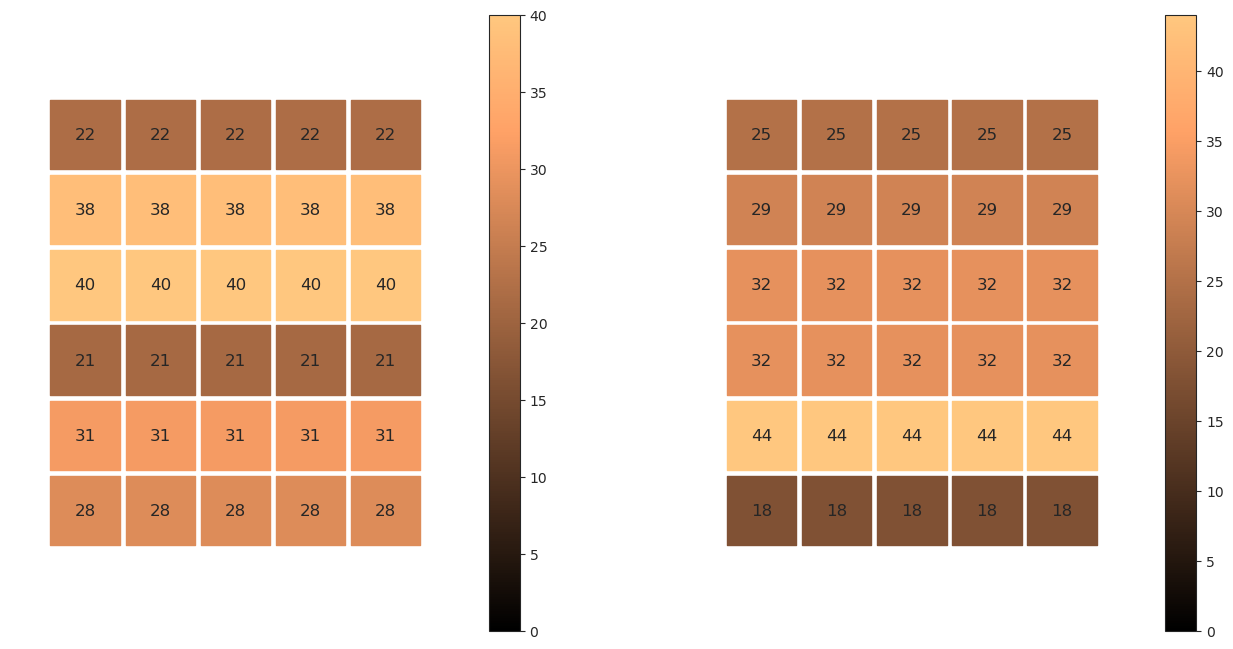

[0.02333333] [0.02]


In [236]:
plot_specs.cmap = 'copper'

try:
    s = plot_specs[parameters.old2new(params.world_type)].marker_size
    marker = plot_specs[parameters.old2new(params.world_type)].marker_shape
except:
    print('exceptiom')
    s, marker = 10, 'H'
#xs, ys = get_node_positions(env, params, plot_specs=plot_specs)
figsize = (16,8)

plt.figure(figsize=figsize) 
for i, env in enumerate([env0, env1]):
    plt.subplot(1,2,i+1)
    pos, bins = np.histogram(pos_timeseries[env], bins=np.arange(n_states[env]+1))
    xs, ys, cell_prepared = env_dict.curric_env.envs[env].get_node_positions(cells=pos, _plot_specs=plot_specs)
    plt.scatter(xs, ys, c=cell_prepared, s=50*50, marker=marker, vmin=0, cmap=plot_specs.cmap)
    plt.xlim(xmin=min(xs)-1, xmax=max(xs)+1)
    plt.ylim(ymin=min(ys)-1, ymax=max(ys)+1)
    plt.xticks([])
    plt.yticks([])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.colorbar()
    for j in range(len(xs)):
        plt.text(xs[j], ys[j], f'{cell_prepared[j]}', 
                ha='center', va='center', fontsize=12)  
plt.show()
print(min(positions[env0]), min(positions[env1]))

In [237]:
# # where the agent didnt go much shown in black
# figsize= (8 * len(envs), 8)

# plt.figure(figsize=figsize)

# for i, env in enumerate([env0, env1]):
#     pos, bins = np.histogram(pos_timeseries[env], bins=np.arange(n_states[env]+1))
#     a = pos > 5
#     plt.subplot(1,2,i+1)
#     xs, ys, cell_prepared = env_dict.curric_env.envs[env].get_node_positions(cells=a.astype(float), _plot_specs=plot_specs)
#     plt.scatter(xs, ys, c=cell_prepared, s=16*8, marker=marker, vmin=0, cmap=plot_specs.cmap)
#     plt.xlim(xmin=min(xs)-1, xmax=max(xs)+1)
#     plt.ylim(ymin=min(ys)-1, ymax=max(ys)+1)
#     plt.gca().set_aspect('equal', adjustable='box')
#     plt.colorbar()    
    
# plt.show()

## ACCURACY MAPS

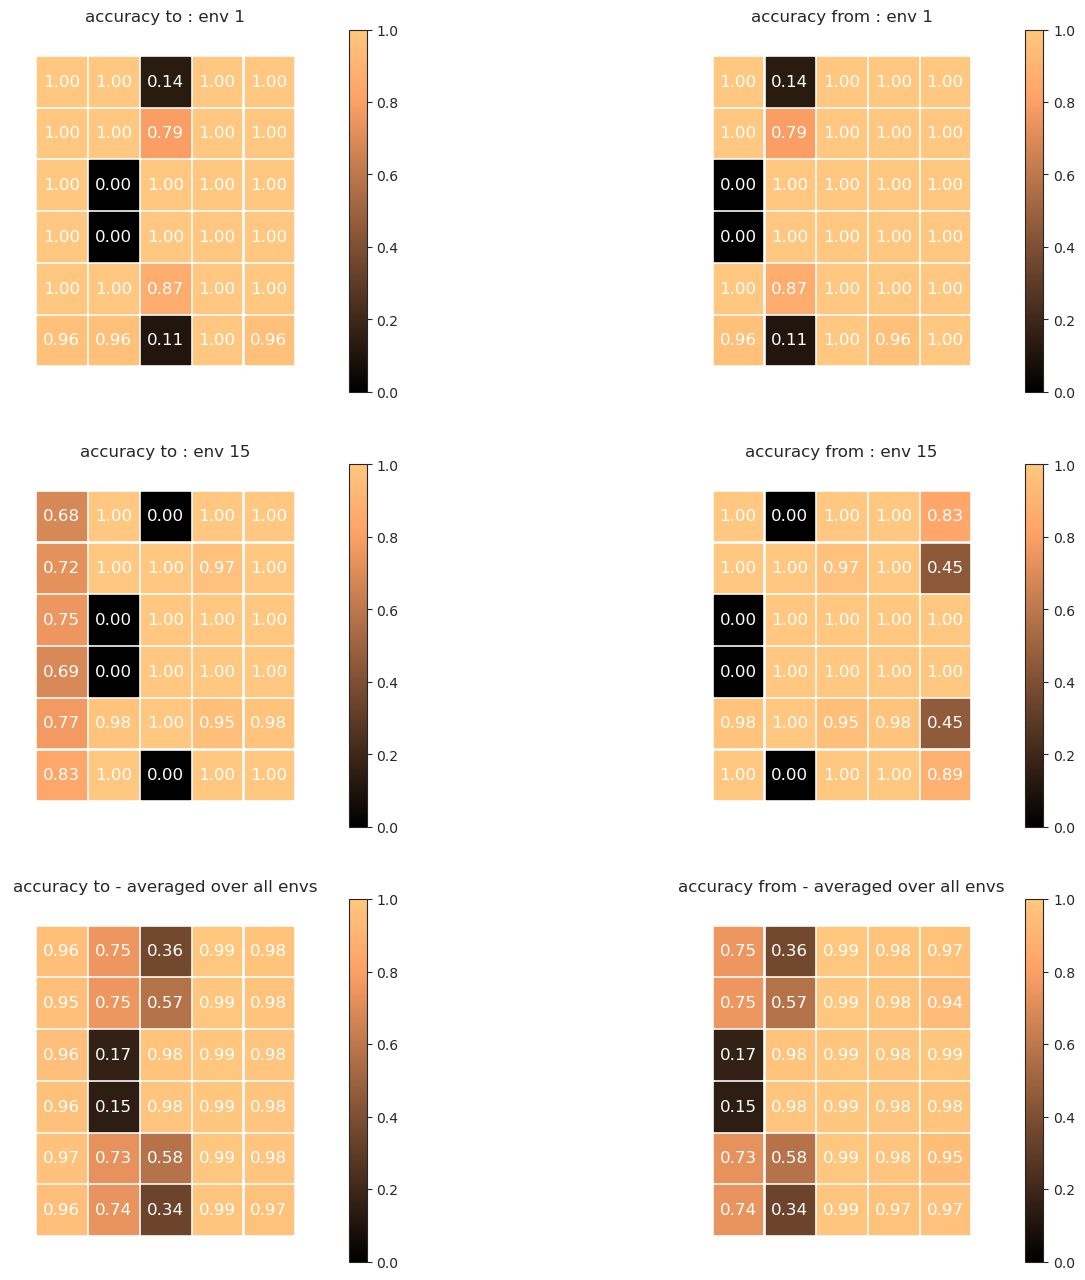

In [238]:
figsize= (8 * len(envs), 16)

plt.figure(figsize=figsize)        
for i, env in enumerate([env0, env1]):
    plt.subplot(3,2,2*i+1)    
    xs, ys, cell_prepared = env_dict.curric_env.envs[env].get_node_positions(cells=acc_s_t_to[env], _plot_specs=plot_specs)
    plt.scatter(xs, ys, c=cell_prepared, cmap=plot_specs.cmap, s=35*35, marker=marker, vmin=0, vmax=1)
    plt.xlim(xmin=min(xs)-1, xmax=max(xs)+1)
    plt.ylim(ymin=min(ys)-1, ymax=max(ys)+1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
    plt.title('accuracy to : env ' + str(env))
    for j in range(len(xs)):
        plt.text(xs[j], ys[j], f'{cell_prepared[j]:.2f}', 
                ha='center', va='center', fontsize=12, color='white')  
        
    plt.subplot(3,2,2*i+2)
    xs, ys, cell_prepared = env_dict.curric_env.envs[env].get_node_positions(cells=acc_s_t_from[env], _plot_specs=plot_specs)
    plt.scatter(xs, ys, c=cell_prepared, cmap=plot_specs.cmap, s=35*35, marker=marker, vmin=0, vmax=1)
    plt.xlim(xmin=min(xs)-1, xmax=max(xs)+1)
    plt.ylim(ymin=min(ys)-1, ymax=max(ys)+1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
    plt.title('accuracy from : env ' + str(env))
    for j in range(len(xs)):
        plt.text(xs[j], ys[j], f'{cell_prepared[j]:.2f}', 
                ha='center', va='center', fontsize=12, color='white')  
    

# average across envs - should do this properly with position counts
env = 0
# find other envs of same size
accs_to = [acc_to for i, acc_to in enumerate(acc_s_t_to) if n_states[i] == n_states[env]]
accs_from = [acc_from for i, acc_from in enumerate(acc_s_t_from) if n_states[i] == n_states[env]]

plt.subplot(3,2,5)
xs, ys, cell_prepared = env_dict.curric_env.envs[env].get_node_positions(cells=np.mean(accs_to, axis=0), _plot_specs=plot_specs)
plt.scatter(xs, ys, c=cell_prepared, cmap=plot_specs.cmap, s=35*35, marker=marker, vmin=0, vmax=1)
plt.xlim(xmin=min(xs)-1, xmax=max(xs)+1)
plt.ylim(ymin=min(ys)-1, ymax=max(ys)+1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.title('accuracy to - averaged over all envs')
plt.gca().set_aspect('equal', adjustable='box')
for j in range(len(xs)):
    plt.text(xs[j], ys[j], f'{cell_prepared[j]:.2f}', 
            ha='center', va='center', fontsize=12, color='white')  
    
plt.subplot(3,2,6)
xs, ys, cell_prepared = env_dict.curric_env.envs[env].get_node_positions(cells=np.mean(accs_from, axis=0), _plot_specs=plot_specs)
plt.scatter(xs, ys, c=cell_prepared, cmap=plot_specs.cmap, s=35*35, marker=marker, vmin=0, vmax=1)
plt.xlim(xmin=min(xs)-1, xmax=max(xs)+1)
plt.ylim(ymin=min(ys)-1, ymax=max(ys)+1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.title('accuracy from - averaged over all envs')
plt.gca().set_aspect('equal', adjustable='box')
for j in range(len(xs)):
    plt.text(xs[j], ys[j], f'{cell_prepared[j]:.2f}', 
            ha='center', va='center', fontsize=12, color='white')  
plt.show()

## ENTORHINAL CELLS

In [239]:

# plot_specs.split_freqs = True
# plot_specs.n_cells_freq = params.n_grids_all
# plot_specs.cmap = 'jet'
# plot_specs.node_plot = False
# plot_specs.max_min = False

In [240]:
# pf.square_plot_smooth(g_all, env0, params, plot_specs, name='g0', lims=g_lim, mask=masks[env0], env_class=env_dict.curric_env.envs[env0], smooth=True)

In [241]:
# pf.square_plot(g_all, env0, params, plot_specs, name='g0', lims=g_lim, mask=masks[env0], env_class=env_dict.curric_env.envs[env0])

## PLACE CELLS

In [242]:

# plot_specs_p = plot_specs
# plot_specs_p.split_freqs = True
# plot_specs_p.n_cells_freq = params.n_place_all
# plot_specs_p.cmap = 'jet'
# plot_specs_p.node_plot = False
# plot_specs_p.max_min = False

In [243]:

# pf.square_plot(p_all, env0, params, plot_specs_p, name='p0', lims=p_lim, mask=masks[env0], env_class=env_dict.curric_env.envs[env0])

In [244]:
'''SABCBCACABCBCABAE'''
# pf.square_plot(p_all, env0, params, plot_specs_p, name='p0', lims=p_lim, mask=masks[env0], env_class=env_dict.curric_env.envs[env0], label = 'p')


'SABCBCACABCBCABAE'

In [245]:
# from matplotlib.colors import LinearSegmentedColormap

# def correlation_heatmap(matrix, labels):
#     corr_matrix = np.corrcoef(matrix)
#     colors = ['#0000FF', '#FFFFFF', '#FF0000']
#     cmap = LinearSegmentedColormap.from_list("my_cmap", colors, N=100)
#     plt.figure(figsize=(6, 5))
    
#     sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap=cmap, 
#                 vmin=0.5, vmax=1)
#     tick_pos = np.arange(0, widths[env0]*6, widths[env0]//5)
#     plt.xticks(tick_pos+0.5, labels, rotation=0)  
#     plt.yticks(tick_pos+0.5, labels, rotation=0)
#     for i in range(5):
#         plt.hlines(xmin=0, xmax= widths[env0] * 6, y=widths[env0]*i+widths[env0], colors='white', linestyles='dashed')
#         plt.vlines(ymin=0, ymax= widths[env0] * 6, x=widths[env0]*i+widths[env0], colors='white', linestyles='dashed')
#     plt.show()
# labels = ['S', 'A', 'B', 'C', 'E', 'S', 'A', 'C', 'B', 'E', 'S', 'B', 'A', 'C', 'E', 'S', 'B', 'C', 'A', 'E', 'S', 'C', 'A', 'B', 'E', 'S', 'C', 'B', 'A', 'E']
# correlation_heatmap(p_all[env0], labels)

In [246]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.rcParams['svg.fonttype'] = 'none'
# def onehot2twohot(onehot, table, compress_size):
#     seq_len = np.shape(onehot)[2]
#     batch_size = np.shape(onehot)[0]
#     twohot = np.zeros((batch_size, compress_size, seq_len))
#     for i in range(np.shape(onehot)[2]):
#         vals = np.argmax(onehot[:, :, i], 1)
#         for b in range(np.shape(onehot)[0]):
#             twohot[b, :, i] = table[vals[int(b)]]

#     return twohot

# p_mat = p_timeseries[env0, :, step].reshape(20, 10)

# n_grids_all = params.n_grids_all     
# n_phases_all = params.n_phases_all    

# g_full = g_timeseries[env0, :, step]  
# g_phase = []
# start = 0
# for n_g, n_ph in zip(n_grids_all, n_phases_all):
#     g_phase.append(g_full[start:start + n_ph])  
#     start += n_g
# g_phase = np.concatenate(g_phase)            
# x_onehot = x_timeseries[env0] 
# x_two_hot = np.dot(params.two_hot_mat.squeeze(), x_onehot[:, :])
# x_vec = x_two_hot[:, step] 

# fig = plt.figure(figsize=(6, 5))
# gs = fig.add_gridspec(2, 2, width_ratios=[0.5, 5], height_ratios=[5, 0.3],
#                       left=0.1, right=0.95, bottom=0.1, top=0.95,
#                       wspace=0.3, hspace=0.3)

# ax_g = fig.add_subplot(gs[0, 0])
# sns.heatmap(g_phase[:, np.newaxis], ax=ax_g, cbar=False, cmap='viridis',
#             xticklabels=False, yticklabels=False)
# ax_g.set_ylabel('downsampled structure code (g)')

# ax_p = fig.add_subplot(gs[0, 1])
# sns.heatmap(p_mat, ax=ax_p, cbar=False, cmap='viridis',
#             xticklabels=False, yticklabels=False)
# ax_p.set_title('conjunctive code (p)')

# ax_x = fig.add_subplot(gs[1, 1])
# sns.heatmap(x_vec[np.newaxis, :], ax=ax_x, cbar=False, cmap='viridis',
#             xticklabels=False, yticklabels=False)
# ax_x.set_xlabel('sensory code (x)')

# plt.savefig("../../plot/fig/p_example.svg", format='svg', bbox_inches='tight')
# plt.show()

In [247]:
# (n_envs, n_steps, g_size)  
n_envs, n_steps, _ = g_all.shape
n_grids_all = params.n_grids_all   
n_phases_all = params.n_phases_all 
total_phases = sum(n_phases_all)  

# (n_envs, n_steps, total_phases)
g_downsample_all = np.zeros((n_envs, n_steps, total_phases))

for env in range(n_envs):
    # g_env: (n_steps, g_size)
    g_env = g_all[env]
    start = 0
    col_idx = 0
    for n_g, n_ph in zip(n_grids_all, n_phases_all):
        g_downsample_all[env, :, col_idx:col_idx+n_ph] = g_env[:, start:start+n_ph]
        start += n_g
        col_idx += n_ph

def onehot2twohot_batch(x_onehot, two_hot_mat):
    if two_hot_mat.ndim == 3:
        two_hot_mat = two_hot_mat.squeeze(0)  # (1, s_size_comp, s_size) -> (s_size_comp, s_size)

    x_twohot = np.matmul(x_onehot, two_hot_mat.T)
    return x_twohot

x_all_onehot = x_all  
two_hot_mat = params.two_hot_mat  
s_size_comp = params.s_size_comp  

x_twohot_all = onehot2twohot_batch(x_all_onehot, two_hot_mat)

In [248]:
# for i in range(30):
#     g_sample = g_downsample_all[env0, i, :].reshape(-1, 1)
#     x_sample = x_twohot_all[env0, i, :].reshape(-1, 1)
#     g_act = np.where(g_sample > 0, g_sample, 0.01 * g_sample)
#     p_sample = np.dot(g_act, x_sample.T).flatten()
#     p_all[env0, i, :] = p_sample

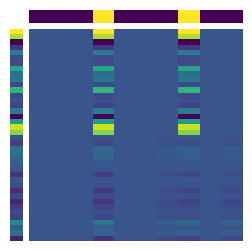

In [249]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec

state = 4

p_data = p_all[env0, state, :].reshape(sum(params.n_grids_all), 10)         
x_data = x_twohot_all[env0, state, :].reshape(1, 10)    
g_data = g_downsample_all[env0, state, :].reshape(sum(params.n_grids_all), 1)         

fig = plt.figure(figsize=(3, 3))
gs = GridSpec(2, 2, width_ratios=[0.5, 8], height_ratios=[0.5, 8], 
              wspace=0.05, hspace=0.05)

ax_main = fig.add_subplot(gs[1, 1])
sns.heatmap(p_data, cmap='viridis', ax=ax_main, cbar=False,
            xticklabels=False, yticklabels=False)

ax_left = fig.add_subplot(gs[1, 0], sharey=ax_main)
sns.heatmap(g_data, cmap='viridis', ax=ax_left, cbar=False,
            xticklabels=False, yticklabels=False)

ax_bottom = fig.add_subplot(gs[0, 1], sharex=ax_main)
sns.heatmap(x_data, cmap='viridis', ax=ax_bottom, cbar=False,
            xticklabels=False, yticklabels=False)

ax_empty = fig.add_subplot(gs[0, 0])
ax_empty.set_visible(False)

plt.show()

In [250]:
data = p_all[env0, :, :]

([], [])

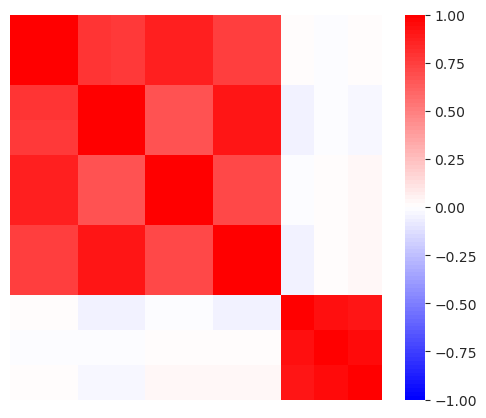

In [251]:
    
'''
A   B   C
1   2   3
A   C   B
6   7   8
B   A   C
11  12  13
B   C   A
16  17  18
C   A   B
21  22  23
C   B   A
26  27  28
'''

from matplotlib.colors import LinearSegmentedColormap

idx = [6, 1, 12, 22, 28, 18, # A1P1 A1P1 A1P2 A2P2 A2P3 A2P3 
        21, 26, 17, 7, 3, 13, # C1P1 C1P1 C1P2 C2P2 C2P3 C2P3
        11, 16, 2, 27, 8, 23] # B1 B1 B2 B2 B3 B3
data_a = np.zeros((11, data.shape[1]))
data_a[0, :] = np.mean(data[idx[0:2], :], axis=0)
data_a[1, :] = np.mean(data[idx[6:8], :], axis=0)
data_a[2, :] = np.mean(data[idx[2:3], :], axis=0)
data_a[3, :] = np.mean(data[idx[8:9], :], axis=0)
data_a[4, :] = np.mean(data[idx[3:4], :], axis=0)
data_a[5, :] = np.mean(data[idx[9:10], :], axis=0)
data_a[6, :] = np.mean(data[idx[4:6], :], axis=0)
data_a[7, :] = np.mean(data[idx[10:12], :], axis=0)
data_a[8, :] = np.mean(data[idx[12:14], :], axis=0)
data_a[9, :] = np.mean(data[idx[14:16], :], axis=0)
data_a[10, :] = np.mean(data[idx[16:18], :], axis=0)
colors = ['#0000FF', '#FFFFFF', '#FF0000']
cmap = LinearSegmentedColormap.from_list("my_cmap", colors, N=100)
dist_euclidean = cdist(data_a, data_a, metric='euclidean')
dist_cosine = cdist(data_a, data_a, metric='cosine')
corr_coef = np.corrcoef(data_a)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_coef, annot=False, fmt=".2f", cmap=cmap, annot_kws={'size': 5},
            vmin=-1, vmax=1)
# plt.hlines([6], 0, 18, colors='black', linestyles='dashed', linewidth=1)
# plt.vlines([6], 0, 18, colors='black', linestyles='dashed', linewidth=1)
# plt.hlines([12], 0, 18, colors='black', linestyles='dashed', linewidth=1)
# plt.vlines([12], 0, 18, colors='black', linestyles='dashed', linewidth=1)

step = [
    'R1P1',
    'R1P2',
    'R2P2',
    'R2P3',
    'B1',
    'B2',
    'B3',
    ]   
# plt.xticks([1,3,5,7,8.5,9.5,10.5], step)
plt.xticks([])
plt.yticks([])

# plt.savefig("../../plot/fig/tem_RSA.svg", format='svg')

[Text(0, 0.5, ''),
 Text(0, 1.5, ''),
 Text(0, 2.5, ''),
 Text(0, 3.5, ''),
 Text(0, 4.5, ''),
 Text(0, 5.5, ''),
 Text(0, 6.5, ''),
 Text(0, 7.5, ''),
 Text(0, 8.5, '')]

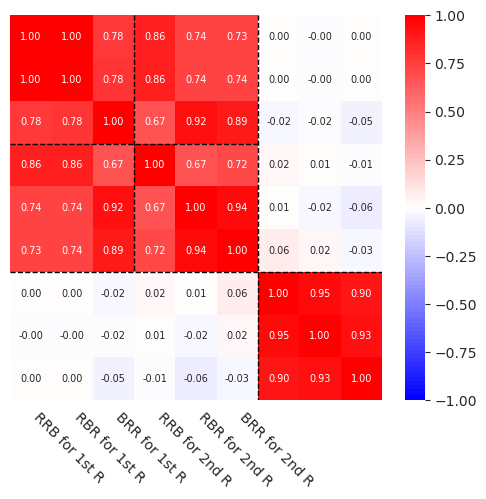

In [252]:
'''
A   B   C
1   2   3
A   C   B
6   7   8
B   A   C
11  12  13
B   C   A
16  17  18
C   A   B
21  22  23
C   B   A
26  27  28
'''

count = 0
for i in range(16):
        count = count + 1
        # idx = [6, 1, 12, 22, 28, 18,
        #         21, 26, 17, 7, 3, 13, 
        #         11, 16, 2, 27, 8, 23]
        data_comp = np.zeros((9, data.shape[1]))
        for i in range(6):
                data_comp[i, :] = data[idx[i], :] + data[idx[6+i], :]
        data_comp[6, :] = data[8, :] + data[23, :]
        data_comp[7, :] = data[2, :] + data[27, :]
        data_comp[8, :] = data[11, :] + data[16, :]
        # data_comp[9, :] = data[0, :] + data[5, :]
        # data_comp[10, :] = data[4, :] + data[9, :]
        if count == 1:
            data_a = data_comp
        else:
            data_a = data_a + data_comp
colors = [ '#0000FF','#FFFFFF', '#FF0000']
cmap = LinearSegmentedColormap.from_list("my_cmap", colors, N=100)

data_a = (data_a - np.mean(data_a))/np.std(data_a)
dist_euclidean = cdist(data_a, data_a, metric='euclidean')
dist_cosine = cdist(data_a, data_a, metric='cosine')
corr_coef = np.corrcoef(data_a)

np.save('../../plot/data/tem_dist_euclidean.npy', dist_euclidean)
np.save('../../plot/data/tem_dist_cosine.npy', dist_cosine)
np.save('../../plot/data/tem_corr_coef.npy', corr_coef)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(corr_coef, annot=True, fmt=".2f", cmap=cmap, annot_kws={'size': 7},
            vmin=-1, vmax=1)
plt.hlines([3], 0, 6, colors='black', linestyles='dashed', linewidth=1)
plt.vlines([3], 0, 6, colors='black', linestyles='dashed', linewidth=1)
plt.hlines([6], 0, 9, colors='black', linestyles='dashed', linewidth=1)
plt.vlines([6], 0, 9, colors='black', linestyles='dashed', linewidth=1)

step = [
    'RRB for 1st R',
    'RBR for 1st R',
    'BRR for 1st R',
    'RRB for 2nd R',
    'RBR for 2nd R',
    'BRR for 2nd R',
    # 'RRB for B',
    # 'RBR for B',
    # 'BRR for B'
    ]
ax.set_xticks(0.5+np.arange(len(step)))      
ax.set_xticklabels(step, rotation=-45, ha='left')
ax.set_yticklabels([])

In [253]:
# tem_statistic = []

In [254]:
# tem_statistic.append(dist_cosine)

In [255]:
# import tensorflow as tf
# g_x_all = np.zeros(g_all.shape)
# for i in range(p_x_all.shape[1]):
#     p_x = p_x_all[:, i, :]
#     mu_attractor_sensum = tf.reduce_mean(
#         tf.reshape(p_x, (model.batch_size, model.par.tot_phases, model.par.s_size_comp)), axis=2)

#     mu_attractor_sensum_ = tf.split(mu_attractor_sensum, num_or_size_splits=model.par.n_phases_all, axis=1)

#     mus = [model.p2g_mu[f](x) for f, x in enumerate(mu_attractor_sensum_)]
#     mu = model.activation(tf.concat(mus, axis=1), 'g')
#     g_x_all[:, i, :] = mu

In [256]:
import plotly.graph_objects as go
import numpy as np
from sklearn.manifold import MDS

max_range = 1
distance = dist_cosine
# Original data
step = [
    'RRB for 1st R', 'RBR for 1st R', 'BRR for 1st R',
    'RRB for 2nd R', 'RBR for 2nd R', 'BRR for 2nd R',
    'RRB for B', 'RBR for B', 'BRR for B']

# Use sorted_steps to define connection order
sorted_steps = [    
    'RRB for 1st R', 'RRB for 2nd R', 'RRB for B',
    'RBR for 1st R', 'RBR for B', 'RBR for 2nd R', 
    'BRR for B', 'BRR for 1st R', 'BRR for 2nd R']

mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
embedding = mds.fit_transform(distance)
embedding = (embedding - embedding.min())/(embedding.max() - embedding.min())

category_groups = {
    'RRB': ['RRB for 1st R', 'RRB for 2nd R', 'RRB for B'],
    'RBR': ['RBR for 1st R', 'RBR for B', 'RBR for 2nd R'], 
    'BRR': ['BRR for B', 'BRR for 1st R', 'BRR for 2nd R']
}

color_map = {'1st R': '#E596B6', '2nd R': '#E596B6', 'B': '#80B8D3'}

fig = go.Figure()

# Color settings
line_colors = {
    'RRB': "#C72828",  # Red
    'RBR': "#1DA49B",  # Cyan
    'BRR': "#F3B118"   # Yellow
}

# First add lines and arrows (bottom layer)
for category, labels_in_category in category_groups.items():
    indices = [i for i, label in enumerate(step) if label in labels_in_category]
    
    # Sort according to order in sorted_steps
    order_map = {label: order for order, label in enumerate(labels_in_category)}
    sorted_indices = sorted(indices, key=lambda i: order_map[step[i]])
    
    if len(indices) > 1:
        # Add lines and arrows for each segment
        for j in range(len(sorted_indices)-1):
            x1, y1, z1 = embedding[sorted_indices[j]]
            x2, y2, z2 = embedding[sorted_indices[j+1]]
            
            # Calculate vector
            dx, dy, dz = x2 - x1, y2 - y1, z2 - z1
            length = np.sqrt(dx**2 + dy**2 + dz**2)
            
            # Shorten by 5% (more than before to leave space for arrows)
            shorten_factor = 0.05
            
            # Start and end points of shortened line
            x_start = x1 + dx * shorten_factor
            y_start = y1 + dy * shorten_factor
            z_start = z1 + dz * shorten_factor
            
            x_end = x2 - dx * shorten_factor
            y_end = y2 - dy * shorten_factor
            z_end = z2 - dz * shorten_factor
            
            # Add line
            fig.add_trace(go.Scatter3d(
                x=[x_start, x_end],
                y=[y_start, y_end],
                z=[z_start, z_end],
                mode='lines',
                line=dict(
                    color=line_colors[category],
                    width=7
                ),
                name=category if j == 0 else '',  # Show legend only for first segment
                showlegend=True if j == 0 else False,
                legendgroup=category,
                hoverinfo='none'
            ))
            
            # Add cone as arrow
            # Arrow position at 100% of the line (at the end)
            arrow_pos = 1
            arrow_x = x_start + (x_end - x_start) * arrow_pos
            arrow_y = y_start + (y_end - y_start) * arrow_pos
            arrow_z = z_start + (z_end - z_start) * arrow_pos
            
            # Arrow direction vector
            u = dx / length
            v = dy / length
            w = dz / length
            
            # Add cone
            fig.add_trace(go.Cone(
                x=[arrow_x],
                y=[arrow_y],
                z=[arrow_z],
                u=[u * 0.1],  # Scale arrow size
                v=[v * 0.1],
                w=[w * 0.1],
                colorscale=[[0, line_colors[category]], [1, line_colors[category]]],
                showscale=False,
                sizemode="absolute",
                sizeref=0.15*length,  # Control arrow size
                anchor="tip",
                showlegend=False
            ))

# Then add points (middle layer)
point_x, point_y, point_z = [], [], []
point_colors = []
point_labels = []

for i, label in enumerate(step):
    reward_label = label.split(' for ')[-1]
    point_color = color_map[reward_label]
    
    point_x.append(embedding[i, 0])
    point_y.append(embedding[i, 1])
    point_z.append(embedding[i, 2])
    point_colors.append(point_color)
    point_labels.append(label)

# Add points
fig.add_trace(go.Scatter3d(
    x=point_x,
    y=point_y,
    z=point_z,
    mode='markers',
    marker=dict(
        size=12,
        color=point_colors,
        opacity=0.9,
        line=dict(width=3, color='darkgray')
    ),
    name='Data Points',
    hoverinfo='text',
    text=point_labels,
    showlegend=False
))

# Last add text (top layer)
text_x, text_y, text_z, text_labels = [], [], [], []

for i, label in enumerate(step):
    # Calculate text offset position (directly above the point)
    offset = 0.05  # Offset value
    
    text_x.append(embedding[i, 0])
    text_y.append(embedding[i, 1])
    text_z.append(embedding[i, 2] + offset)
    text_labels.append(label)


# Add legend for reward states
fig.add_trace(go.Scatter3d(
    x=[None],
    y=[None],
    z=[None],
    mode='markers',
    marker=dict(
        size=10,
        color='#E596B6',
        symbol='circle',
        opacity=1,
        line=dict(width=1, color='black')
    ),
    name='Reward State',
    showlegend=True
))

fig.add_trace(go.Scatter3d(
    x=[None],
    y=[None],
    z=[None],
    mode='markers',
    marker=dict(
        size=10,
        color='#80B8D3',
        symbol='circle',
        opacity=1,
        line=dict(width=1, color='black')
    ),
    name='No-Reward State',
    showlegend=True
))
fig.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='white',
    scene=dict(
        bgcolor='white',
        aspectmode='cube',
        xaxis=dict(
            showticklabels=False,
            showgrid=True,
            gridcolor='lightgray',
            gridwidth=2,
            showline=True,
            linecolor='black',
            linewidth=4,
            ticks='',
            showbackground=False,
            zeroline=False,
            title=dict(text=''),  
            range=[0, max_range]
        ),
        yaxis=dict(
            showticklabels=False,
            showgrid=True,
            gridcolor='lightgray',
            gridwidth=2,
            showline=True,
            linecolor='black',
            linewidth=4,
            ticks='',
            showbackground=False,
            zeroline=False,
            title=dict(text=''), 
            range=[0, max_range]
        ),
        zaxis=dict(
            showticklabels=False,
            showgrid=True,
            gridcolor='lightgray',
            gridwidth=2,
            showline=True,
            linecolor='black',
            linewidth=4,
            ticks='',
            showbackground=False,
            zeroline=False,
            title=dict(text=''),  
            range=[0, max_range]
        ),
        annotations=[
            dict(
                showarrow=False,
                x=max_range/2,  
                y=0,
                z=0,
                text="",
                textangle=0,
                ax=0,
                ay=0,
                font=dict(
                    color="black",
                    size=30,
                    family="Times New Roman"
                ),

                xanchor="center", 
                yanchor="middle",  
            ),
            dict(
                showarrow=False,
                x=0,
                y=max_range/2,  
                z=0,
                text="",
                textangle=0,
                ax=0,
                ay=0,
                font=dict(
                    color="black",
                    size=30,
                    family="Times New Roman"
                ),
                xanchor="center",
                yanchor="middle",
            ),
            dict(
                showarrow=False,
                x=0,
                y=1.5,
                z=max_range,  
                text="MDS3",
                textangle=0,
                ax=0,
                ay=0,
                font=dict(
                    color="black",
                    size=30,
                    family="Times New Roman"
                ),
                xanchor="center",
                yanchor="middle",
            ),
        ],
        camera=dict(
            up=dict(x=0, y=0, z=1),  # Keep z as up direction
            center=dict(x=0, y=0, z=0),
            eye=dict(x=-1.8, y=-1, z=1),  # Adjusted for better alignment
            projection=dict(type='orthographic')
        )
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left", 
        x=0.01,
        font=dict(size=20, family='Times NewRoman'),
        bordercolor="rgba(0,0,0,0)",  # Transparent border
        borderwidth=0,  # No border
        bgcolor="rgba(255,255,255,0.8)"  # Semi-transparent background
    ),
    width=900,
    height=700,
    font=dict(family="Arial", size=20)
)

fig.show()


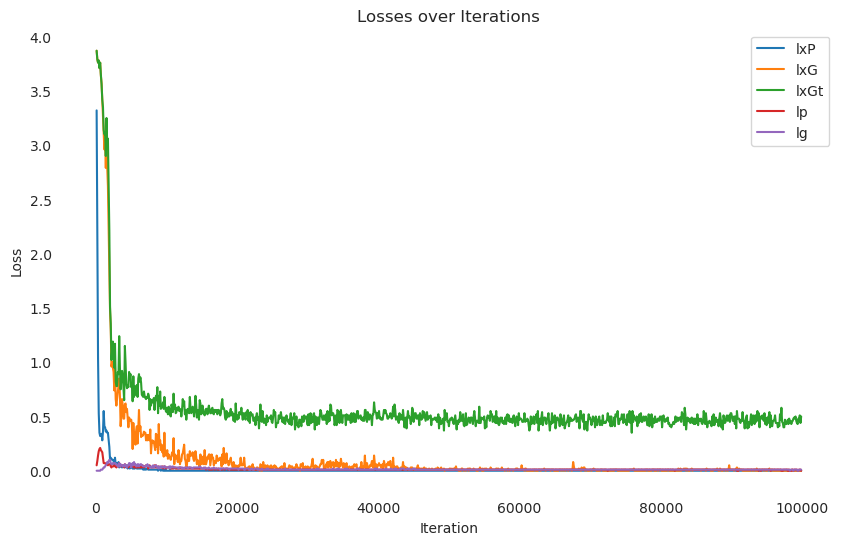

In [257]:
import re

log_file_path = save_dir + date + '/run' + str(run) + '/summaries.log'

losses_data = []

with open(log_file_path, "r") as log_file:
    for line in log_file:
        match = re.match(r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3}): it=(\d+), lxP=(\d+\.\d+), lxG=(\d+\.\d+), lxGt=(\d+\.\d+), lp=(\d+\.\d+), lg=(\d+\.\d+), aP=(\d+\.\d+), aGinf=(\d+\.\d+), aGt=(\d+\.\d+)", line)
        if match:
            
            iteration = int(match.group(2))
            lx_p = float(match.group(3))
            lx_g = float(match.group(4))
            lx_gt = float(match.group(5))
            lp = float(match.group(6))
            lg = float(match.group(7))
            aP = float(match.group(8))
            aGinf = float(match.group(9))
            aGt = float(match.group(10))
            
            losses_data.append({
                "iteration": iteration,
                "lx_p": lx_p,
                "lx_g": lx_g,
                "lx_gt": lx_gt,
                "lp": lp,
                "lg": lg,
                "aP": aP,
                "aGinf": aGinf,
                "aGt": aGt
            })

iterations = [data["iteration"] for data in losses_data]
lx_p = [data["lx_p"] for data in losses_data]
lx_g = [data["lx_g"] for data in losses_data]
lx_gt = [data["lx_gt"] for data in losses_data]
lp = [data["lp"] for data in losses_data]
lg = [data["lg"] for data in losses_data]

plt.figure(figsize=(10, 6))
plt.plot(iterations, lx_p, label="lxP")
plt.plot(iterations, lx_g, label="lxG")
plt.plot(iterations, lx_gt, label="lxGt")
plt.plot(iterations, lp, label="lp")
plt.plot(iterations, lg, label="lg")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Losses over Iterations")

plt.show()

In [258]:
width = widths[env0]

# the data type order: ABC ACB BAC BCA CAB CBA
g_type_mean = np.array([g_all[env0, (i*width): ((i+1)*width)] for i in range(6)])
g_type_std = np.array([g_all_std[env0, (i*width): ((i+1)*width)] for i in range(6)])
p_type_mean = np.array([p_all[env0, (i*width): ((i+1)*width)] for i in range(6)])
p_type_std = np.array([p_all_std[env0, (i*width): ((i+1)*width)] for i in range(6)])

type = ['ABC', 'CBA', 'ACB', 'CAB', 'BAC', 'BCA']

# type order: ABC CBA ACB CAB BAC BCA
mean_data_mat = p_type_mean[[0, 5, 1, 4, 2, 3], ...]
std_data_mat = p_type_std[[0, 5, 1, 4, 2, 3], ...]

sort_type = 0

In [259]:
np.save('../../plot/data/tem_g_cell_mean.npy', g_type_mean[[0, 5, 1, 4, 2, 3], ...])
np.save('../../plot/data/tem_g_cell_std.npy', g_type_std[[0, 5, 1, 4, 2, 3], ...])
np.save('../../plot/data/tem_p_cell_mean.npy', p_type_mean[[0, 5, 1, 4, 2, 3], ...])
np.save('../../plot/data/tem_p_cell_std.npy', p_type_std[[0, 5, 1, 4, 2, 3], ...])

In [260]:
# ABC CBA ACB CAB BAC BCA

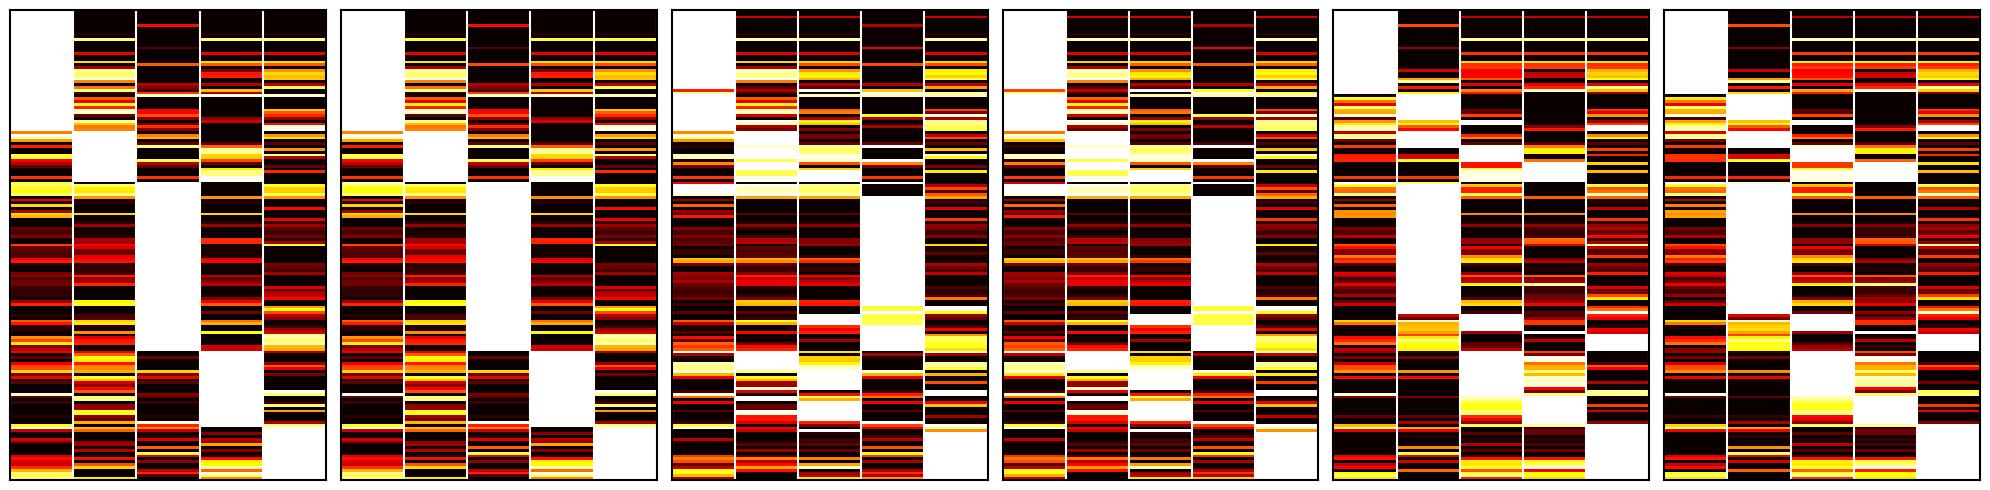

In [261]:
col_max_idx = []
for i in range(6):
    current_col_max = np.max(mean_data_mat[i], axis=0)
    current_zero_mask = current_col_max == 0
    
    current_col_max_idx = np.argmax(mean_data_mat[i], axis=0)
    current_col_max_idx[current_zero_mask] = -1  
    
    col_max_idx.append(current_col_max_idx)

col_max_idx_array = np.stack(col_max_idx) 

identical_col_mask = np.all(col_max_idx_array == col_max_idx_array[0, :], axis=0)
firing_col_mask = np.all(col_max_idx_array != -1, axis=0)
firing_col_idx = np.where(firing_col_mask)[0]
place_col_idx = np.where(identical_col_mask)[0]
task_col_idx = np.where(~identical_col_mask & firing_col_mask)[0]
sort_trial_type = 0
sort_cell_type = firing_col_idx
secondary_keys = []
for i in range(6):
    if i != sort_trial_type:
        secondary_keys.append(col_max_idx_array[i, sort_cell_type])
all_keys = secondary_keys + [col_max_idx_array[sort_trial_type, sort_cell_type]]
sort_idx = np.lexsort(all_keys)

# np.save('../plot/data/wta_cell_mat.npy', data_mat[:, :, sort_cell_type[sort_idx]].T)
fig, axes = plt.subplots(1, 6, figsize=(20, 5)) 
axes = axes.ravel()
for i in range(6):
    data_matrix = mean_data_mat[i]
    col_mins = np.min(data_matrix, axis=0)
    col_maxs = np.max(data_matrix, axis=0)
    ranges = col_maxs - col_mins
    ranges[ranges == 0] = 1 
    data_matrix = (data_matrix - col_mins) / ranges
    sorted_matrix = data_matrix[:, :]
    for j in range(6):
        axes[i].vlines(x=j, ymin=0, ymax=data_matrix.shape[1], colors='w')
    sns.heatmap(sorted_matrix[:, sort_cell_type[sort_idx]].T, 
                ax=axes[i], 
                cmap='hot', 
                cbar=False,  
                xticklabels=False, 
                yticklabels=False)  
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)         
        spine.set_edgecolor('black') 
    # axes[i].set_title(f'Type: {type_order[i]}')

    
plt.tight_layout()
plt.show()

# fig.savefig('../../plot/fig/tem_cell_heatmap.svg', format='svg')

In [262]:
neurons = [] #sort_cell_type[sort_idx][:].tolist()

In [263]:
n_timesteps = 5
mean_data_type_reshaped = mean_data_mat
std_data_type_reshaped = std_data_mat

for neuron_idx in neurons:
    # Extract mean and std for the selected neuron
    neuron_activities_mean = []
    neuron_activities_std = []

    for i in range(6):
        neuron_mean = mean_data_type_reshaped[i, :, neuron_idx]
        neuron_std = std_data_type_reshaped[i, :, neuron_idx]
        neuron_activities_mean.append(neuron_mean)
        neuron_activities_std.append(neuron_std)

    neuron_activities_mean = np.array(neuron_activities_mean) 
    neuron_activities_std = np.array(neuron_activities_std)   

    # Generate stimulus sequences
    stim_sequences = []
    for trial_type_str in type:
        sequence = ['S'] + list(trial_type_str) + ['E']
        stim_sequences.append(sequence)

    # Define color scheme
    reward_color = '#E596B6'  # Reward location background
    trial_colors = ['#1DA49B', '#1DA49B',  # ABC, CBA
                    '#C72828', '#C72828',  # ACB, CAB
                    '#F3B118', '#F3B118']  # BAC, BCA

    # Create figure with slightly larger size to ensure borders are visible
    fig, axes = plt.subplots(2, 3, figsize=(6, 2), sharey=True, sharex=True)
    axes = axes.T.ravel()  # Transpose to get column-major order

    # Calculate unified y-axis range
    all_means = neuron_activities_mean.flatten()
    all_stds = neuron_activities_std.flatten()
    y_min = (all_means - all_stds).min()
    y_max = (all_means + all_stds).max()
    # Add a small margin to prevent data touching borders
    y_margin = (y_max - y_min) * 0.05
    y_min -= y_margin
    y_max += y_margin

    # Plot each trial type
    for i in range(6):
        ax = axes[i]
        
        trial_means = neuron_activities_mean[i]
        # trial_means = (trial_means - trial_means.min()) / (trial_means.max() - trial_means.min() + 1e-10)
        trial_stds = neuron_activities_std[i]
        time_points = range(n_timesteps)
        
        # Mark reward positions
        for t, stim in enumerate(stim_sequences[i]):
            if stim in ['A', 'C']:  # A and C have rewards
                ax.axvspan(t-0.5, t+0.5, alpha=0.2, color=reward_color, 
                        zorder=0, linewidth=0)
        
        # Add light vertical lines between time steps
        for t in np.arange(-0.5, n_timesteps-0.5, 1):
            ax.axvline(x=t, color='lightgray', alpha=0.3, 
                    zorder=1, linewidth=0.8, linestyle='-')
        
        # Plot mean curve
        line, = ax.plot(time_points, trial_means, 
                        linewidth=1.8, marker='o', markersize=3.5,
                        color=trial_colors[i], zorder=3, markeredgecolor='white', 
                        markeredgewidth=0.5)
        
        # Plot standard deviation range
        ax.fill_between(time_points, 
                        trial_means - trial_stds, 
                        trial_means + trial_stds, 
                        alpha=0.2, color=trial_colors[i],
                        zorder=2, linewidth=0)
        
        # Set x-axis ticks (empty to hide labels but keep ticks)
        ax.set_xticks(time_points)
        ax.set_xticklabels([])
        
        # Set y-axis range
        ax.set_ylim(y_min, y_max)
        
        # Ensure all borders are visible - explicitly set each spine
        for spine in ['top', 'bottom', 'left', 'right']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(0.8)
            ax.spines[spine].set_color('black')
        
        # Set x-axis range
        ax.set_xlim(-0.5, n_timesteps-0.5)
        
        # Set subplot title
        ax.set_title(f'{type[i]}', fontsize=9, pad=3, 
                    color=trial_colors[i], fontweight='bold')
        
        # Add subtle horizontal grid
        ax.grid(True, axis='y', alpha=0.1, linestyle='-', zorder=1, linewidth=0.3)
        
        # Ensure tick marks are visible
        ax.tick_params(axis='both', which='both', 
                    bottom=True, top=False, left=True, right=False,
                    length=3, width=0.5, labelsize=8)

    # Set global labels
    fig.text(0.5, 0.01, 'Time Step', ha='center', fontsize=9, fontweight='medium')
    fig.text(0.01, 0.5, 'Activity (a.u.)', va='center', rotation='vertical', 
            fontsize=9, fontweight='medium')

    # Adjust layout with more padding to ensure borders are visible
    plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.95], pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.show()

In [264]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# import numpy as np

# # 您提供的字母序列
# sequences = [
#     ['S', 'A', 'B', 'C', 'E'],
#     ['S', 'A', 'C', 'B', 'E'],
#     ['S', 'B', 'A', 'C', 'E'],
#     ['S', 'B', 'C', 'A', 'E'],
#     ['S', 'C', 'A', 'B', 'E'],
#     ['S', 'C', 'B', 'A', 'E']
# ]
# sequences = [
#     ['S', 'R', 'N', 'R', 'E'],
#     ['S', 'R', 'R', 'N', 'E'],
#     ['S', 'N', 'R', 'R', 'E'],
#     ['S', 'N', 'R', 'R', 'E'],
#     ['S', 'R', 'R', 'N', 'E'],
#     ['S', 'R', 'N', 'R', 'E']
# ]
# # 字母颜色映射（使用和谐的颜色搭配）
# color_map = {
#     'A': '#FF6B6B',  # 柔和的红色
#     'R': '#E596B6',  # 柔和的红色
#     'B': '#4CC9F0',  # 明亮的蓝色
#     'N': '#80B8D3',  # 明亮的蓝色
#     'C': '#FFD166',  # 柔和的黄色
#     'S': '#78BC97',  # 灰蓝色
#     'E': '#9D9D9D'   # 灰蓝色（与S相同）
# }

# # 创建图形和坐标轴
# fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# # 网格参数
# nrows = len(sequences)
# ncols = len(sequences[0])
# cell_size = 0.1 


# for i, sequence in enumerate(sequences):
#     for j, letter in enumerate(sequence):
#         x = j * cell_size-0.5
#         y = (nrows - 1 - i) * cell_size -0.5
        
#         rect = patches.Rectangle(
#             (x, y), cell_size, cell_size,
#             facecolor=color_map[letter],
#             edgecolor='white',  
#             linewidth=2,
#             alpha=0.9
#         )
#         ax.add_patch(rect)
        
#         ax.text(
#             x + cell_size/2, y + cell_size/2, letter,
#             fontsize=16, fontweight='bold',
#             color='white',
#             ha='center', va='center'
#         )

# # 设置坐标轴范围
# ax.set_xlim(-0.5, ncols * cell_size - 0.5)
# ax.set_ylim(-0.5, nrows * cell_size - 0.5)

# ax.set_xticks([])
# ax.set_yticks([])
# ax.axis('off')

# # 显示图形
# plt.show()